# Higher-Order Aberrated Gaussian Diagnostics

This notebook focuses on smooth aberrated lens phases. It measures how non-quadratic a strong Krivanek phase is over already-propagated Gaussian supports, then checks how a real-space Gaussian split reduces the local residual.


## Setup

This notebook runs on the default JAX backend. If a CUDA backend is visible, the sampled residual and Gaussian splitting checks can use the GPU; otherwise JAX falls back to CPU.


In [1]:
import os

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.4")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.components import Detector, KrivanekLens
from temgym_core.constants import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_for
from temgym_core.gaussian import FreeSpacePropagator, make_gaussian
from temgym_core.gaussian_corrections import (
    apply_taylor_phase_action,
    estimate_width_scale_for_residual,
    first_order_phase_residual_correction_factor,
    fit_phase_residual_polynomial_on_beam,
    sampled_quadratic_residual_on_beam,
    split_gaussian_realspace,
)
from temgym_core.source import circular_input_wave
from temgym_core.utils import FresnelPropagator, zero_phase

jax.config.update("jax_enable_x64", True)
print("JAX backend:", jax.devices()[0].platform)


JAX backend: gpu


## Aberrated Lens Residual And Splitting Check

This local check measures how non-quadratic a strong Krivanek phase is over the current Gaussian supports, then shows how a 5x5 split reduces the worst local residual. It is intentionally separate from the atom notebook so we can extend it with FFT probe comparisons next.


Input beams: 114
Parent residual rad median/p90/max: 0.7355801668687636 0.7355988970087752 0.7356062249449812
Worst split child residual rad median/p90/max: 0.15889070354870205 0.15889395280674506 0.15889435216172973
Estimated width scale for 0.25 rad target: 0.6978544801754474


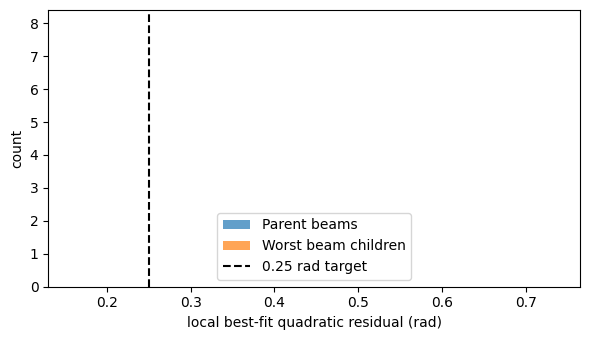

In [2]:
voltage_lens = 300_000
aperture_radius = 0.15e-6
focal_length = 5e-3

coeffs = KrivanekCoeffs(
    C21=300.0,
    phi21=0.25 * jnp.pi,
    C23=120.0,
    phi23=-0.1 * jnp.pi,
    C32=150.0,
    phi32=0.4 * jnp.pi,
    C43=150.0,
    phi43=0.2 * jnp.pi,
)
lens = KrivanekLens(z=focal_length, focal_length=focal_length, coeffs=coeffs)
rays_in = circular_input_wave(
    aperture_radius=aperture_radius,
    waist=0.05e-6,
    voltage=voltage_lens,
    overlap_factor=2.0,
)
rays_at_lens = FreeSpacePropagator()(rays_in, focal_length)

residuals = []
for i in range(int(np.asarray(rays_at_lens.x).size)):
    ray_i = rays_at_lens[i]
    residual = sampled_quadratic_residual_on_beam(
        lambda xy: lens.phase_shift(xy),
        ray_i,
        scale=ray_i.k,
        support_radius=1.0,
        fit_samples_per_axis=5,
    )
    residuals.append(float(residual.max_abs))
residuals = np.asarray(residuals)

worst_idx = int(np.argmax(residuals))
worst_children = split_gaussian_realspace(
    rays_at_lens[worst_idx],
    grid_shape=(5, 5),
    support_radius=1.1,
    child_width_scale=0.6,
)
child_residuals = []
for i in range(int(np.asarray(worst_children.x).size)):
    child_i = worst_children[i]
    residual = sampled_quadratic_residual_on_beam(
        lambda xy: lens.phase_shift(xy),
        child_i,
        scale=child_i.k,
        support_radius=1.0,
        fit_samples_per_axis=5,
    )
    child_residuals.append(float(residual.max_abs))
child_residuals = np.asarray(child_residuals)

print(f"Input beams: {np.asarray(rays_in.x).size}")
print(
    "Parent residual rad median/p90/max:",
    np.median(residuals),
    np.quantile(residuals, 0.9),
    np.max(residuals),
)
print(
    "Worst split child residual rad median/p90/max:",
    np.median(child_residuals),
    np.quantile(child_residuals, 0.9),
    np.max(child_residuals),
)
print(
    "Estimated width scale for 0.25 rad target:",
    float(estimate_width_scale_for_residual(np.max(residuals), target=0.25)),
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(residuals, bins=20, alpha=0.7, label="Parent beams")
ax.hist(child_residuals, bins=12, alpha=0.7, label="Worst beam children")
ax.axvline(0.25, color="k", linestyle="--", label="0.25 rad target")
ax.set_xlabel("local best-fit quadratic residual (rad)")
ax.set_ylabel("count")
ax.legend()
fig.tight_layout()
plt.show()

## End-To-End Probe Check Against Fresnel Propagation

The residual histogram above is local. This check uses a sampled Fresnel propagation through the exact Krivanek phase mask as the reference, then compares Taylor propagation with a first-order Hermite/Gaussian correction from the cubic-and-higher Taylor residual.

In [3]:
def block_until_ready(value):
    def block_leaf(x):
        return x.block_until_ready() if hasattr(x, "block_until_ready") else x

    return jax.tree_util.tree_map(block_leaf, value)


def center_zero_phase(field):
    return zero_phase(field, field.shape[0] // 2, field.shape[1] // 2)


def aligned_field_error(test, ref):
    alpha = jnp.vdot(test, ref) / jnp.vdot(test, test)
    return float(jnp.linalg.norm(alpha * test - ref) / jnp.linalg.norm(ref))


def normalized_intensity_error(test, ref):
    test_i = jnp.abs(test) ** 2
    ref_i = jnp.abs(ref) ** 2
    test_i = test_i / jnp.sum(test_i)
    ref_i = ref_i / jnp.sum(ref_i)
    return float(jnp.linalg.norm(test_i - ref_i) / jnp.linalg.norm(ref_i))


probe_voltage = 300_000
probe_focal_length = 5e-3
probe_coeff_scale = 0.25
probe_waist = 0.03e-6
probe_window_width = 2.0e-6
probe_shape = (128, 128)
probe_pixel = probe_window_width / probe_shape[0]

probe_lens_grid = Detector(
    z=probe_focal_length,
    pixel_size=(probe_pixel, probe_pixel),
    shape=probe_shape,
)
probe_detector = Detector(
    z=2 * probe_focal_length,
    pixel_size=(probe_pixel, probe_pixel),
    shape=probe_shape,
)

probe_wavelength = energy2wavelength(probe_voltage)
probe_k = 2 * jnp.pi / probe_wavelength
probe_coeffs = KrivanekCoeffs(
    C21=probe_coeff_scale * 300.0,
    phi21=0.25 * jnp.pi,
    C23=probe_coeff_scale * 120.0,
    phi23=-0.1 * jnp.pi,
    C32=probe_coeff_scale * 150.0,
    phi32=0.4 * jnp.pi,
    C43=probe_coeff_scale * 150.0,
    phi43=0.2 * jnp.pi,
)
probe_lens = KrivanekLens(
    z=probe_focal_length,
    focal_length=probe_focal_length,
    coeffs=probe_coeffs,
)
probe_in = make_gaussian(
    x=0.0,
    y=0.0,
    z=probe_focal_length,
    voltage=probe_voltage,
    waist_x=probe_waist,
    waist_y=probe_waist,
)

input_probe_field = block_until_ready(
    center_zero_phase(evaluate_gaussians_for(probe_in, probe_lens_grid))
)
probe_phase_mask = jax.vmap(probe_lens.phase_shift)(
    probe_lens_grid.coords
).reshape(probe_lens_grid.shape)
fresnel_probe = FresnelPropagator(
    input_probe_field * jnp.exp(1j * probe_k * probe_phase_mask),
    L=probe_window_width,
    wavelength=probe_wavelength,
    z=probe_focal_length,
)
fresnel_probe = block_until_ready(center_zero_phase(fresnel_probe))

taylor_probe = apply_taylor_phase_action(probe_in, probe_lens.phase_shift)
gaussian_probe = FreeSpacePropagator()(taylor_probe, probe_focal_length)
gaussian_probe_field = block_until_ready(
    center_zero_phase(evaluate_gaussians_for(gaussian_probe, probe_detector))
)

residual_fit = fit_phase_residual_polynomial_on_beam(
    probe_lens.phase_shift,
    probe_in,
    min_degree=3,
    max_degree=4,
    fit_support_radius=1.0,
    fit_samples_per_axis=7,
)
hermite_factor = first_order_phase_residual_correction_factor(
    taylor_probe,
    probe_detector.coords,
    probe_focal_length,
    residual_fit,
).reshape(probe_detector.shape)
hermite_probe_field = block_until_ready(
    center_zero_phase(gaussian_probe_field * (1.0 + hermite_factor))
)

taylor_field_error = aligned_field_error(gaussian_probe_field, fresnel_probe)
taylor_intensity_error = normalized_intensity_error(gaussian_probe_field, fresnel_probe)
hermite_field_error = aligned_field_error(hermite_probe_field, fresnel_probe)
hermite_intensity_error = normalized_intensity_error(hermite_probe_field, fresnel_probe)
print(f"Taylor field error after global phase/amplitude alignment: {taylor_field_error:.4g}")
print(f"Taylor normalized intensity error: {taylor_intensity_error:.4g}")
print(f"Hermite first-order field error after global phase/amplitude alignment: {hermite_field_error:.4g}")
print(f"Hermite first-order normalized intensity error: {hermite_intensity_error:.4g}")
print(f"Max |Hermite correction factor|: {float(jnp.max(jnp.abs(hermite_factor))):.4g}")
print(f"Fresnel peak amplitude: {float(jnp.max(jnp.abs(fresnel_probe))):.4g}")
print(f"Taylor peak amplitude: {float(jnp.max(jnp.abs(gaussian_probe_field))):.4g}")
print(f"Hermite peak amplitude: {float(jnp.max(jnp.abs(hermite_probe_field))):.4g}")

Taylor field error after global phase/amplitude alignment: 0.01137
Taylor normalized intensity error: 0.01901
Hermite first-order field error after global phase/amplitude alignment: 0.0003627
Hermite first-order normalized intensity error: 0.0005654
Max |Hermite correction factor|: 24.81
Fresnel peak amplitude: 0.2849
Taylor peak amplitude: 0.284
Hermite peak amplitude: 0.2851


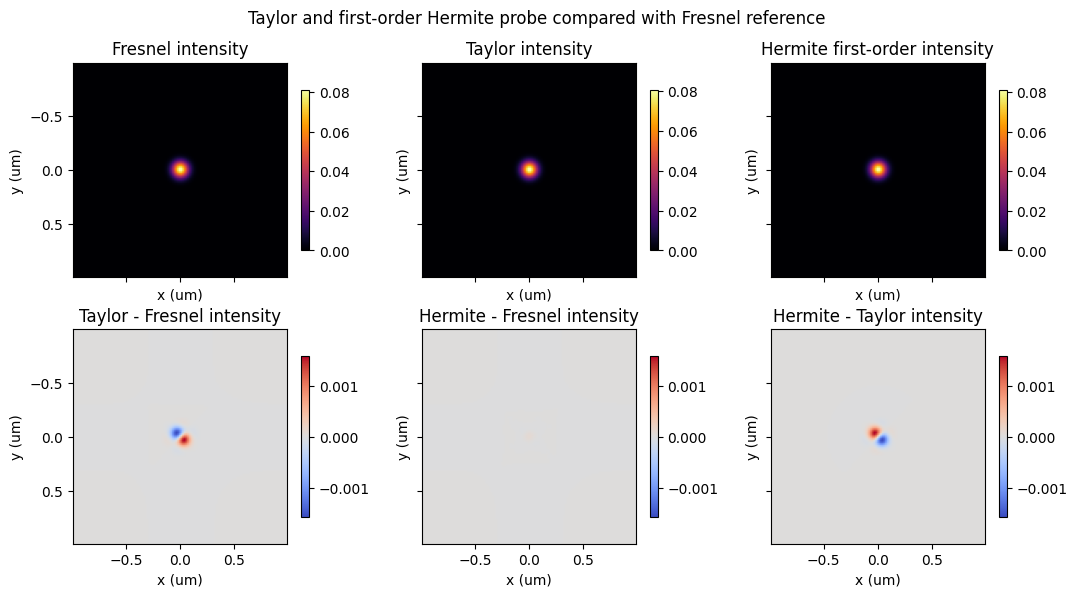

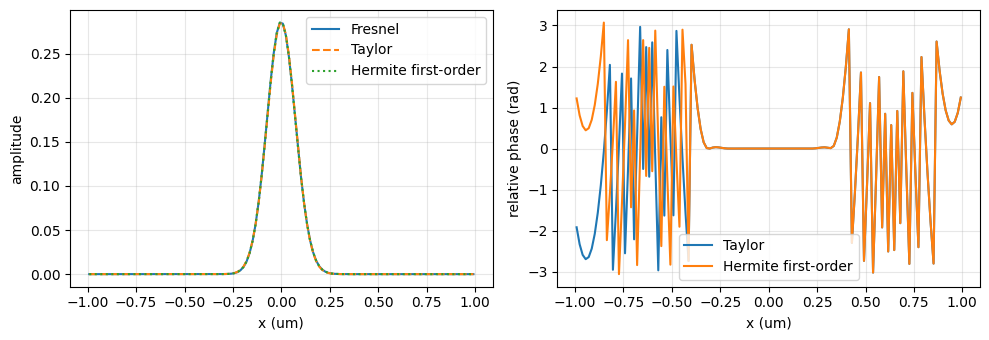

In [4]:
probe_extent_um = tuple(float(v) * 1e6 for v in probe_detector.extent)
fresnel_np = np.asarray(fresnel_probe)
gaussian_np = np.asarray(gaussian_probe_field)
hermite_np = np.asarray(hermite_probe_field)
fresnel_intensity = np.abs(fresnel_np) ** 2
gaussian_intensity = np.abs(gaussian_np) ** 2
hermite_intensity = np.abs(hermite_np) ** 2
taylor_difference = gaussian_intensity - fresnel_intensity
hermite_difference = hermite_intensity - fresnel_intensity
difference_limit = max(np.max(np.abs(taylor_difference)), np.max(np.abs(hermite_difference)))

fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)
images = [
    (fresnel_intensity, "Fresnel intensity", "inferno", None),
    (gaussian_intensity, "Taylor intensity", "inferno", None),
    (hermite_intensity, "Hermite first-order intensity", "inferno", None),
    (taylor_difference, "Taylor - Fresnel intensity", "coolwarm", difference_limit),
    (hermite_difference, "Hermite - Fresnel intensity", "coolwarm", difference_limit),
    (hermite_intensity - gaussian_intensity, "Hermite - Taylor intensity", "coolwarm", difference_limit),
]
for ax, (data, title, cmap, limit) in zip(axes.ravel(), images):
    kwargs = {}
    if limit is not None and limit > 0:
        kwargs.update(vmin=-limit, vmax=limit)
    im = ax.imshow(data, extent=probe_extent_um, origin="lower", cmap=cmap, **kwargs)
    ax.set_title(title)
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.suptitle("Taylor and first-order Hermite probe compared with Fresnel reference")
fig.tight_layout()
plt.show()

x_um = np.asarray(probe_detector.coords_1d[0]) * 1e6
center_y = probe_shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(x_um, np.abs(fresnel_np[center_y, :]), label="Fresnel")
axes[0].plot(x_um, np.abs(gaussian_np[center_y, :]), "--", label="Taylor")
axes[0].plot(x_um, np.abs(hermite_np[center_y, :]), ":", label="Hermite first-order")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("amplitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_um, np.angle(gaussian_np[center_y, :] * np.conj(fresnel_np[center_y, :])), label="Taylor")
axes[1].plot(x_um, np.angle(hermite_np[center_y, :] * np.conj(fresnel_np[center_y, :])), label="Hermite first-order")
axes[1].set_xlabel("x (um)")
axes[1].set_ylabel("relative phase (rad)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()